In [ ]:
import polars as pl

In [7]:
## assume data is already downloaded from lab and stored in data/ folder

1. Data reading
   - load all 2024 months of taxi rides
   - also load taxi zone lookup data
   - include only rides starting in 2024 and ending at most at 01.01.2025
   - optimize data types, particularly for integers and categorical strings

In [ ]:
DATA_DIR = "data"
taxi_zones = pl.scan_csv(f"{DATA_DIR}/taxi_zone_lookup.csv")

dfs = []
for month in range(1, 13):
    lf = pl.scan_parquet(f"{DATA_DIR}/{month}.parquet")
    lf = lf.with_columns(
        pl.col("tpep_pickup_datetime").dt.cast_time_unit("ms"),
        pl.col("tpep_dropoff_datetime").dt.cast_time_unit("ms"),
    )
    dfs.append(lf)

rides = (
    pl.concat(dfs)
    .filter(
        pl.col("tpep_pickup_datetime") >= pl.datetime(2024, 1, 1),
        pl.col("tpep_dropoff_datetime") <= pl.datetime(2025, 1, 1),
    )
    .with_columns(
        pl.col("VendorID").cast(pl.Int8),
        pl.col("passenger_count").cast(pl.Int8),
        pl.col("RatecodeID").cast(pl.Int8),
        pl.col("store_and_fwd_flag").cast(pl.Categorical),
        pl.col("PULocationID").cast(pl.Int16),
        pl.col("DOLocationID").cast(pl.Int16),
        pl.col("payment_type").cast(pl.Int8),
    )
)

print(rides.explain())

 WITH_COLUMNS:
 [col("VendorID").strict_cast(Int8), col("passenger_count").strict_cast(Int8), col("RatecodeID").strict_cast(Int8), col("store_and_fwd_flag").strict_cast(Categorical(None, Physical)), col("PULocationID").strict_cast(Int16), col("DOLocationID").strict_cast(Int16), col("payment_type").strict_cast(Int8)] 
  UNION
    PLAN 0:
      FILTER [([(col("tpep_dropoff_datetime")) <= (2025-01-01 00:00:00.cast(Datetime(Milliseconds, None)))]) & ([(col("tpep_pickup_datetime")) >= (2024-01-01 00:00:00.cast(Datetime(Milliseconds, None)))])] FROM
         WITH_COLUMNS:
         [col("tpep_pickup_datetime").dt.cast_time_unit(), col("tpep_dropoff_datetime").dt.cast_time_unit()] 
          Parquet SCAN [data/1.parquet]
          PROJECT */19 COLUMNS
    PLAN 1:
      FILTER [([(col("tpep_dropoff_datetime")) <= (2025-01-01 00:00:00.cast(Datetime(Milliseconds, None)))]) & ([(col("tpep_pickup_datetime")) >= (2024-01-01 00:00:00.cast(Datetime(Milliseconds, None)))])] FROM
         WITH_COLUMNS:


In [12]:
rides.head(5).collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i8,datetime[ms],datetime[ms],i8,f64,i8,cat,i16,i16,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",186,79,2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0


In [13]:
print("Taxi zones schema:")
print(taxi_zones.collect_schema())
taxi_zones.head(5).collect()

Taxi zones schema:
Schema([('LocationID', Int64), ('Borough', String), ('Zone', String), ('service_zone', String)])


LocationID,Borough,Zone,service_zone
i64,str,str,str
1,"""EWR""","""Newark Airport""","""EWR"""
2,"""Queens""","""Jamaica Bay""","""Boro Zone"""
3,"""Bronx""","""Allerton/Pelham Gardens""","""Boro Zone"""
4,"""Manhattan""","""Alphabet City""","""Yellow Zone"""
5,"""Staten Island""","""Arden Heights""","""Boro Zone"""


2. Data cleaning and filtering
   - fill NULL values in `passengers_count` with 1
   - remove rides with zero passengers
   - if a ride has over 6 passengers, replace the value with 6
   - remove rides lasting over 2 hours
   - in all money-related columns, replace values with absolute value to fix negative amounts
   - remove rides with over 1000 dollars in any money-related column
   - remove rows with values of `RatecodeID` or `VendorID` missing or outside those defined in the data dictionary

In [20]:
MONEY_COLS = [
    "fare_amount", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "congestion_surcharge", "Airport_fee",
]

rides_clean = (
    rides
    .with_columns(pl.col("passenger_count").fill_null(1))
    .filter(pl.col("passenger_count") > 0)
    .with_columns(
        pl.when(pl.col("passenger_count") > 6)
        .then(6)
        .otherwise(pl.col("passenger_count"))
        .alias("passenger_count")
    )
    # remove rides lasting over 2 hours
    .filter(
        (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
        <= pl.duration(hours=2)
    )
    .with_columns(pl.col(MONEY_COLS).abs())
    .filter(pl.all_horizontal(pl.col(MONEY_COLS) <= 1000))
    .filter(pl.col("VendorID").is_not_null() & pl.col("VendorID").is_in([1, 2, 6, 7]))
    #99 = Null/unknown skipping
    .filter(pl.col("RatecodeID").is_not_null() & pl.col("RatecodeID").is_in([1, 2, 3, 4, 5, 6]))
)

print(rides_clean.explain())

FILTER [([([([([([([([([(col("Airport_fee")) <= (1000.0)]) & ([(col("tip_amount")) <= (1000.0)])]) & ([(col("tolls_amount")) <= (1000.0)])]) & ([(col("mta_tax")) <= (1000.0)])]) & ([(col("extra")) <= (1000.0)])]) & ([(col("improvement_surcharge")) <= (1000.0)])]) & ([(col("total_amount")) <= (1000.0)])]) & ([(col("fare_amount")) <= (1000.0)])]) & ([(col("congestion_surcharge")) <= (1000.0)])] FROM
   WITH_COLUMNS:
   [when([(col("passenger_count")) > (6)]).then(6).otherwise(col("passenger_count")).alias("passenger_count"), col("fare_amount").abs(), col("extra").abs(), col("mta_tax").abs(), col("tip_amount").abs(), col("tolls_amount").abs(), col("improvement_surcharge").abs(), col("total_amount").abs(), col("congestion_surcharge").abs(), col("Airport_fee").abs()] 
    FILTER [(col("passenger_count")) > (0)] FROM
       WITH_COLUMNS:
       [col("passenger_count").fill_null([1])] 
        FILTER [([(col("VendorID").is_in([Series])) & (col("VendorID").is_not_null())]) & ([(col("RatecodeID

In [21]:
rides_clean.head(5).collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i8,datetime[ms],datetime[ms],i8,f64,i8,cat,i16,i16,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",186,79,2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0


In [24]:
rides_clean.collect()['VendorID'].value_counts()

VendorID,count
i8,u32
7,230
1,7990437
2,28194765


In [25]:
rides_clean.collect()['RatecodeID'].value_counts()

RatecodeID,count
i8,u32
4,100063
3,128363
2,1394259
6,68
1,34245525
5,317154


3. Data transformation
   - combine payment type values for `"No charge"`, `"Dispute"`, `"Unknown"` and `"Voided trip"` into one type,
     so we have only credit card, cash, or other
   - replace `PULocationID` and `DOLocationID` with borough names by joining taxi zone lookup and removing
     unnecessary columns
   - add boolean variable `is_airport_ride`, true if there is non-zero airport fee
   - add boolean variable `is_rush_hour`, rush hours are defined as 6:30–9:30 and 15:30-20:00 during weekdays

In [36]:
pu_zones = taxi_zones.select(
    pl.col("LocationID").alias("PULocationID"),
    pl.col("Borough").alias("PU_borough"),
)
do_zones = taxi_zones.select(
    pl.col("LocationID").alias("DOLocationID"),
    pl.col("Borough").alias("DO_borough"),
)

pickup_time = pl.col("tpep_pickup_datetime")

rides_transformed = (
    rides_clean
    # payment_type: 1=credit card, 2=cash, 0, 3, 4, 5, 6 = 3 (other)
    .with_columns(
        pl.when(pl.col("payment_type").is_in([1, 2]))
        .then(pl.col("payment_type"))
        .otherwise(pl.lit(3, dtype=pl.Int8))
        .alias("payment_type")
    )
    # jak w labie polaczenie  po pu i do
    .join(pu_zones, on="PULocationID", how="left")
    .drop("PULocationID")
    .join(do_zones, on="DOLocationID", how="left")
    .drop("DOLocationID")
    .with_columns(
        (pl.col("Airport_fee") > 0).alias("is_airport_ride"),
    )
    # is_rush_hour: weekday (Mon=1..Fri=5) AND (6:30-9:30 OR 15:30-20:00)
    .with_columns(
        (
            # weekdays (Monday=1 to Friday=5)
            (pl.col("tpep_pickup_datetime").dt.weekday() <= 5)
            & (
                # 6:30-9:30 OR 15:30-20:00
                pl.col("tpep_pickup_datetime").dt.time().is_between(pl.time(6, 30), pl.time(9, 30))
                | pl.col("tpep_pickup_datetime").dt.time().is_between(pl.time(15, 30), pl.time(20, 0))
            )
        ).alias("is_rush_hour")
    )
)

print(rides_transformed.collect_schema())

Schema([('VendorID', Int8), ('tpep_pickup_datetime', Datetime(time_unit='ms', time_zone=None)), ('tpep_dropoff_datetime', Datetime(time_unit='ms', time_zone=None)), ('passenger_count', Int8), ('trip_distance', Float64), ('RatecodeID', Int8), ('store_and_fwd_flag', Categorical(ordering='physical')), ('payment_type', Int8), ('fare_amount', Float64), ('extra', Float64), ('mta_tax', Float64), ('tip_amount', Float64), ('tolls_amount', Float64), ('improvement_surcharge', Float64), ('total_amount', Float64), ('congestion_surcharge', Float64), ('Airport_fee', Float64), ('PU_borough', String), ('DO_borough', String), ('is_airport_ride', Boolean), ('is_rush_hour', Boolean)])


In [37]:
rides_transformed.head(5).collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,PU_borough,DO_borough,is_airport_ride,is_rush_hour
i8,datetime[ms],datetime[ms],i8,f64,i8,cat,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,bool,bool
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0,"""Manhattan""","""Manhattan""",false,false
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,"""Manhattan""","""Manhattan""",false,false
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0,"""Manhattan""","""Manhattan""",false,false
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0,"""Manhattan""","""Manhattan""",false,false
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0,"""Manhattan""","""Manhattan""",false,false


4. Feature extraction
   - apply dummy encoding to features:
     - payment type
     - pickup borough
     - dropoff borough
   - add integer variables for counting daily events:
     - total number of rides (target variable)
     - number of airport rides
     - number of rush hour rides
   - add features aggregating daily rides information:
     - average fare amount
     - median distance
     - sum of total amounts
     - total amount paid by card, cash, and other
     - total congestion surcharge
     - total number of passengers
   - add time features:
     - `quarter`
     - `month`
     - `day_of_month`
     - `day_of_week`
     - `is_weekend` (boolean)
   - add column `date`, indicating day with given features
   - make sure to exclude other columns, unnecessary for machine learning, e.g. IDs, timestamps, unused financial information
   - properly name all columns
   - save results as `dataset.parquet` file

In [ ]:
# BOROUGHS = sorted(taxi_zones.select("Borough").unique().collect()["Borough"].to_list())
# print("Boroughs:", BOROUGHS)

Boroughs: ['Bronx', 'Brooklyn', 'EWR', 'Manhattan', 'N/A', 'Queens', 'Staten Island', 'Unknown']


In [48]:
rides_with_features.shape

(36185432, 22)

In [57]:
rides_with_features = (
    rides_transformed
    .with_columns([
        pl.col("tpep_pickup_datetime").dt.date().alias("date"),
        
        # Taka zamiana będzie potrzeba w nastepnym kroku, ale elegancko jest to zrobic od razu
        # zamiast labelek - stringi z oznaczeniem typu platnosci
        pl.when(pl.col("payment_type") == 1).then(pl.col("total_amount")).otherwise(0).alias("total_amount_credit_card"),
        pl.when(pl.col("payment_type") == 2).then(pl.col("total_amount")).otherwise(0).alias("total_amount_cash"),
        pl.when(pl.col("payment_type") == 3).then(pl.col("total_amount")).otherwise(0).alias("total_amount_other"),
    ])
    .collect()
)

rides_with_dummies = rides_with_features.to_dummies(
    columns=["payment_type", "PU_borough", "DO_borough"]
)

In [58]:
rides_with_dummies.shape

(36185432, 41)

In [59]:
type(rides_with_dummies) # no longer a graph - actual data variable

polars.dataframe.frame.DataFrame

Group by date and aggregate

In [60]:
rides_with_dummies.columns

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'payment_type_1',
 'payment_type_2',
 'payment_type_3',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'PU_borough_Bronx',
 'PU_borough_Brooklyn',
 'PU_borough_EWR',
 'PU_borough_Manhattan',
 'PU_borough_N/A',
 'PU_borough_Queens',
 'PU_borough_Staten Island',
 'PU_borough_Unknown',
 'DO_borough_Bronx',
 'DO_borough_Brooklyn',
 'DO_borough_EWR',
 'DO_borough_Manhattan',
 'DO_borough_N/A',
 'DO_borough_Queens',
 'DO_borough_Staten Island',
 'DO_borough_Unknown',
 'is_airport_ride',
 'is_rush_hour',
 'date',
 'total_amount_credit_card',
 'total_amount_cash',
 'total_amount_other']

In [ ]:
#"The goal is to predict the daily number of taxi rides in the future, based
# on historical features"
# z uwagi na taka tresc zadania robie agregacje do dzinnych danych a nie funkcje okienkowe.

dummy_col_names = [
    c for c in rides_with_dummies.columns
    if c.startswith("payment_type_") or c.startswith("PU_borough_") or c.startswith("DO_borough_")
]

daily = (
    rides_with_dummies
    .group_by("date")
    .agg(
        pl.len().alias("total_rides"),
        pl.col("is_airport_ride").sum().alias("airport_rides"),
        pl.col("is_rush_hour").sum().alias("rush_hour_rides"),

        #agregacje z tresci zadania
        pl.col("fare_amount").mean().alias("avg_fare_amount"),
        pl.col("trip_distance").median().alias("median_distance"),
        pl.col("total_amount").sum().alias("sum_total_amount"),
        pl.col("total_amount_credit_card").sum().alias("total_paid_credit_card"),
        pl.col("total_amount_cash").sum().alias("total_paid_cash"),
        pl.col("total_amount_other").sum().alias("total_paid_other"),
        pl.col("congestion_surcharge").sum().alias("total_congestion_surcharge"),
        pl.col("passenger_count").cast(pl.Int32).sum().alias("total_passengers"),

        # sum of all dummy columns (daily count per category)
        *[pl.col(name).sum() for name in dummy_col_names],
    )
)

print(daily.schema)

Schema([('date', Date), ('total_rides', UInt32), ('airport_rides', UInt32), ('rush_hour_rides', UInt32), ('avg_fare_amount', Float64), ('median_distance', Float64), ('sum_total_amount', Float64), ('total_paid_credit_card', Float64), ('total_paid_cash', Float64), ('total_paid_other', Float64), ('total_congestion_surcharge', Float64), ('total_passengers', Int32), ('payment_type_1', Int64), ('payment_type_2', Int64), ('payment_type_3', Int64), ('PU_borough_Bronx', Int64), ('PU_borough_Brooklyn', Int64), ('PU_borough_EWR', Int64), ('PU_borough_Manhattan', Int64), ('PU_borough_N/A', Int64), ('PU_borough_Queens', Int64), ('PU_borough_Staten Island', Int64), ('PU_borough_Unknown', Int64), ('DO_borough_Bronx', Int64), ('DO_borough_Brooklyn', Int64), ('DO_borough_EWR', Int64), ('DO_borough_Manhattan', Int64), ('DO_borough_N/A', Int64), ('DO_borough_Queens', Int64), ('DO_borough_Staten Island', Int64), ('DO_borough_Unknown', Int64)])


In [62]:
daily

date,total_rides,airport_rides,rush_hour_rides,avg_fare_amount,median_distance,sum_total_amount,total_paid_credit_card,total_paid_cash,total_paid_other,total_congestion_surcharge,total_passengers,payment_type_1,payment_type_2,payment_type_3,PU_borough_Bronx,PU_borough_Brooklyn,PU_borough_EWR,PU_borough_Manhattan,PU_borough_N/A,PU_borough_Queens,PU_borough_Staten Island,PU_borough_Unknown,DO_borough_Bronx,DO_borough_Brooklyn,DO_borough_EWR,DO_borough_Manhattan,DO_borough_N/A,DO_borough_Queens,DO_borough_Staten Island,DO_borough_Unknown
date,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,i32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
2024-12-28,81437,6848,0,20.185737,1.69,2.3216e6,1.7808e6,431258.45,109513.49,187202.5,127761,60049,17306,4082,58,362,21,71557,81,9116,6,236,468,3418,266,72233,425,4306,26,295
2024-12-01,87365,13964,0,22.378566,1.85,2.7922e6,2.3566e6,331371.3,104228.04,196883.5,124832,70412,13304,3649,41,476,22,71444,83,15005,6,288,403,4342,270,75715,590,5623,19,403
2024-08-22,87813,9493,34951,20.811519,1.77,2.6667e6,2.1993e6,379450.32,87944.58,202257.5,117884,70560,14237,3016,55,370,25,76702,58,10349,6,248,546,3713,287,77320,551,5021,35,340
2024-04-01,84155,10051,35257,20.114442,1.77,2.5084e6,2.0851e6,362248.46,61123.81,193802.5,115475,67606,14273,2276,34,234,11,72619,43,10911,1,302,477,2861,240,74996,427,4691,35,428
2024-07-29,81745,10144,34560,20.317662,1.75,2.4416e6,2.0029e6,357360.12,81292.88,186280.0,110081,64992,13941,2812,66,269,16,70034,52,11046,4,258,475,3050,205,72031,535,5063,24,362
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2024-11-19,110077,9063,46418,19.462151,1.63,3.1929e6,2.7638e6,344740.2,84328.13,259815.0,136664,93059,13970,3048,36,304,11,99444,43,9906,3,330,354,3403,223,100390,450,4807,23,427
2024-02-19,71729,9895,28161,20.506389,1.82,2.1340e6,1.7971e6,289728.58,47214.87,162892.5,100480,57541,12246,1942,35,217,20,60271,37,10887,1,261,393,2923,274,62672,339,4720,14,394
2024-07-05,66705,6921,26071,19.648428,1.73,1.9096e6,1.4720e6,357208.74,80313.51,151942.5,100652,49538,14307,2860,80,331,6,58385,57,7638,5,203,514,2537,188,58849,466,3894,31,226


Add time features

In [63]:
date_col = pl.col("date")

dataset = (
    daily
    .with_columns(
        date_col.dt.quarter().alias("quarter"),
        date_col.dt.month().alias("month"),
        date_col.dt.day().alias("day_of_month"),
        date_col.dt.weekday().alias("day_of_week"),
        (date_col.dt.weekday() > 5).alias("is_weekend"),
    )
    .sort("date")
)

print(dataset.collect_schema())

Schema([('date', Date), ('total_rides', UInt32), ('airport_rides', UInt32), ('rush_hour_rides', UInt32), ('avg_fare_amount', Float64), ('median_distance', Float64), ('sum_total_amount', Float64), ('total_paid_credit_card', Float64), ('total_paid_cash', Float64), ('total_paid_other', Float64), ('total_congestion_surcharge', Float64), ('total_passengers', Int32), ('payment_type_1', Int64), ('payment_type_2', Int64), ('payment_type_3', Int64), ('PU_borough_Bronx', Int64), ('PU_borough_Brooklyn', Int64), ('PU_borough_EWR', Int64), ('PU_borough_Manhattan', Int64), ('PU_borough_N/A', Int64), ('PU_borough_Queens', Int64), ('PU_borough_Staten Island', Int64), ('PU_borough_Unknown', Int64), ('DO_borough_Bronx', Int64), ('DO_borough_Brooklyn', Int64), ('DO_borough_EWR', Int64), ('DO_borough_Manhattan', Int64), ('DO_borough_N/A', Int64), ('DO_borough_Queens', Int64), ('DO_borough_Staten Island', Int64), ('DO_borough_Unknown', Int64), ('quarter', Int8), ('month', Int8), ('day_of_month', Int8), ('d

In [66]:
dataset.head()

date,total_rides,airport_rides,rush_hour_rides,avg_fare_amount,median_distance,sum_total_amount,total_paid_credit_card,total_paid_cash,total_paid_other,total_congestion_surcharge,total_passengers,payment_type_1,payment_type_2,payment_type_3,PU_borough_Bronx,PU_borough_Brooklyn,PU_borough_EWR,PU_borough_Manhattan,PU_borough_N/A,PU_borough_Queens,PU_borough_Staten Island,PU_borough_Unknown,DO_borough_Bronx,DO_borough_Brooklyn,DO_borough_EWR,DO_borough_Manhattan,DO_borough_N/A,DO_borough_Queens,DO_borough_Staten Island,DO_borough_Unknown,quarter,month,day_of_month,day_of_week,is_weekend
date,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,i32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i8,i8,i8,i8,bool
2024-01-01,69541,8352,19360,22.184388,2.09,2.1793e6,1.7389e6,384662.67,55778.86,156123.25,109013,52846,14491,2204,60,627,21,59231,93,9235,3,271,559,3785,388,58579,605,5150,31,444,1,1,1,1,false
2024-01-02,71443,9828,30554,21.312124,1.8,2.2095e6,1.7617e6,396334.47,51441.03,160615.0,102927,54034,15387,2022,34,232,20,60126,54,10709,2,266,433,2979,319,62212,432,4651,32,385,1,1,2,2,false
2024-01-03,78399,9140,32924,19.968751,1.72,2.2900e6,1.8242e6,416241.57,49554.25,177985.0,109805,60176,16202,2021,48,301,16,67701,36,9981,1,315,498,3124,282,69273,395,4340,14,473,1,1,3,3,false
2024-01-04,97896,8270,43112,18.68711,1.73,2.7179e6,2.2134e6,444631.77,59823.2,226627.5,134634,77557,17994,2345,42,257,10,88136,39,9026,1,385,596,3089,226,88692,344,4386,14,549,1,1,4,4,false
2024-01-05,97958,7460,40150,18.114238,1.7,2.6451e6,2.1666e6,420694.52,57798.23,227540.0,136260,77801,17697,2460,47,298,8,88955,37,8218,1,394,536,2889,222,89122,342,4220,20,607,1,1,5,5,false


In [67]:
dataset.write_parquet("dataset.parquet")
print(f"Saved dataset.parquet with shape {dataset.shape}")

Saved dataset.parquet with shape (366, 36)


5. Data analysis
   - print shape
   - show top rows
   - describe statistics
   - print schema
   - plot target variable (daily number of rides):
     - histogram of values
     - line plot, date vs number of rides (remember to sort by date)

In [68]:
import matplotlib.pyplot as plt
dataset = pl.read_parquet("dataset.parquet")


In [ ]:
#shape
dataset.shape

(366, 36)

In [ ]:
# shwow top rows
dataset.head()

show top rows


date,total_rides,airport_rides,rush_hour_rides,avg_fare_amount,median_distance,sum_total_amount,total_paid_credit_card,total_paid_cash,total_paid_other,total_congestion_surcharge,total_passengers,payment_type_1,payment_type_2,payment_type_3,PU_borough_Bronx,PU_borough_Brooklyn,PU_borough_EWR,PU_borough_Manhattan,PU_borough_N/A,PU_borough_Queens,PU_borough_Staten Island,PU_borough_Unknown,DO_borough_Bronx,DO_borough_Brooklyn,DO_borough_EWR,DO_borough_Manhattan,DO_borough_N/A,DO_borough_Queens,DO_borough_Staten Island,DO_borough_Unknown,quarter,month,day_of_month,day_of_week,is_weekend
date,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,i32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i8,i8,i8,i8,bool
2024-01-01,69541,8352,19360,22.184388,2.09,2.1793e6,1.7389e6,384662.67,55778.86,156123.25,109013,52846,14491,2204,60,627,21,59231,93,9235,3,271,559,3785,388,58579,605,5150,31,444,1,1,1,1,false
2024-01-02,71443,9828,30554,21.312124,1.8,2.2095e6,1.7617e6,396334.47,51441.03,160615.0,102927,54034,15387,2022,34,232,20,60126,54,10709,2,266,433,2979,319,62212,432,4651,32,385,1,1,2,2,false
2024-01-03,78399,9140,32924,19.968751,1.72,2.2900e6,1.8242e6,416241.57,49554.25,177985.0,109805,60176,16202,2021,48,301,16,67701,36,9981,1,315,498,3124,282,69273,395,4340,14,473,1,1,3,3,false
2024-01-04,97896,8270,43112,18.68711,1.73,2.7179e6,2.2134e6,444631.77,59823.2,226627.5,134634,77557,17994,2345,42,257,10,88136,39,9026,1,385,596,3089,226,88692,344,4386,14,549,1,1,4,4,false
2024-01-05,97958,7460,40150,18.114238,1.7,2.6451e6,2.1666e6,420694.52,57798.23,227540.0,136260,77801,17697,2460,47,298,8,88955,37,8218,1,394,536,2889,222,89122,342,4220,20,607,1,1,5,5,false


In [72]:
#describe statistics
dataset.describe()



statistic,date,total_rides,airport_rides,rush_hour_rides,avg_fare_amount,median_distance,sum_total_amount,total_paid_credit_card,total_paid_cash,total_paid_other,total_congestion_surcharge,total_passengers,payment_type_1,payment_type_2,payment_type_3,PU_borough_Bronx,PU_borough_Brooklyn,PU_borough_EWR,PU_borough_Manhattan,PU_borough_N/A,PU_borough_Queens,PU_borough_Staten Island,PU_borough_Unknown,DO_borough_Bronx,DO_borough_Brooklyn,DO_borough_EWR,DO_borough_Manhattan,DO_borough_N/A,DO_borough_Queens,DO_borough_Staten Island,DO_borough_Unknown,quarter,month,day_of_month,day_of_week,is_weekend
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""366""",366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2024-07-01 12:00:00""",98867.300546,8977.81694,29516.784153,19.786164,1.703374,2.8672e6,2.4169e6,372223.376667,78109.084344,230200.254153,133727.789617,81014.688525,14922.306011,2930.306011,47.15847,385.043716,15.983607,88141.330601,59.322404,9903.31694,2.52459,312.620219,457.505464,3542.344262,284.52459,88606.437158,482.677596,5019.855191,25.188525,448.76776,2.505464,6.513661,15.756831,3.986339,0.284153
"""std""",null,15192.844685,1716.370323,19423.582497,1.206237,0.102174,453452.472008,420941.772074,36187.455655,17245.96652,37863.324471,18672.609688,13981.900044,1357.096824,553.633249,13.637459,133.64075,7.71263,15101.870988,17.819334,1751.757443,1.677636,57.292717,60.144426,554.266329,73.624208,14603.050048,93.595837,681.010364,6.723093,92.084524,1.119551,3.455958,8.823592,2.006108,null
"""min""","""2024-01-01""",46930.0,3355.0,0.0,16.623276,1.5,1.3081e6,978705.28,240633.43,41303.84,107820.0,73723.0,33594.0,10244.0,1656.0,22.0,167.0,2.0,41627.0,23.0,4814.0,0.0,149.0,312.0,1663.0,122.0,41529.0,260.0,2739.0,9.0,192.0,1.0,1.0,1.0,1.0,0.0
"""25%""","""2024-04-01""",88657.0,7869.0,0.0,18.945217,1.64,2.5439e6,2.1289e6,352425.45,65781.9,203501.0,121081.0,71633.0,14108.0,2566.0,37.0,288.0,10.0,76908.0,45.0,8741.0,1.0,273.0,415.0,3181.0,236.0,78336.0,416.0,4569.0,20.0,390.0,2.0,4.0,8.0,2.0,null
"""50%""","""2024-07-02""",99489.0,9018.0,38944.0,19.751554,1.69,2.8746e6,2.4310e6,375876.77,79216.96,232817.5,132914.0,82258.0,14965.0,2909.0,45.0,353.0,15.0,89401.0,58.0,9854.0,2.0,310.0,451.0,3494.0,275.0,89785.0,480.0,5029.0,25.0,444.0,3.0,7.0,16.0,4.0,null
"""75%""","""2024-10-01""",109654.0,10144.0,44107.0,20.549493,1.75,3.1880e6,2.6994e6,398461.95,90101.99,256939.5,145601.0,90472.0,15832.0,3271.0,55.0,443.0,20.0,99037.0,70.0,11056.0,3.0,347.0,492.0,3877.0,335.0,98951.0,545.0,5511.0,30.0,515.0,4.0,10.0,23.0,6.0,null
"""max""","""2024-12-31""",140079.0,14903.0,55965.0,24.370708,2.2,4.4077e6,3.8619e6,449947.01,123886.72,330475.0,198656.0,119382.0,17994.0,4596.0,129.0,939.0,47.0,127844.0,125.0,15890.0,8.0,505.0,669.0,5544.0,583.0,127102.0,716.0,6710.0,51.0,718.0,4.0,12.0,31.0,7.0,1.0


In [74]:
#schema
#tu mozna zrobić casta na typy o mniejszym rozmiarze, obecnie są zbyt zasobochłonne
dataset.schema

Schema([('date', Date),
        ('total_rides', UInt32),
        ('airport_rides', UInt32),
        ('rush_hour_rides', UInt32),
        ('avg_fare_amount', Float64),
        ('median_distance', Float64),
        ('sum_total_amount', Float64),
        ('total_paid_credit_card', Float64),
        ('total_paid_cash', Float64),
        ('total_paid_other', Float64),
        ('total_congestion_surcharge', Float64),
        ('total_passengers', Int32),
        ('payment_type_1', Int64),
        ('payment_type_2', Int64),
        ('payment_type_3', Int64),
        ('PU_borough_Bronx', Int64),
        ('PU_borough_Brooklyn', Int64),
        ('PU_borough_EWR', Int64),
        ('PU_borough_Manhattan', Int64),
        ('PU_borough_N/A', Int64),
        ('PU_borough_Queens', Int64),
        ('PU_borough_Staten Island', Int64),
        ('PU_borough_Unknown', Int64),
        ('DO_borough_Bronx', Int64),
        ('DO_borough_Brooklyn', Int64),
        ('DO_borough_EWR', Int64),
        ('DO_borough_

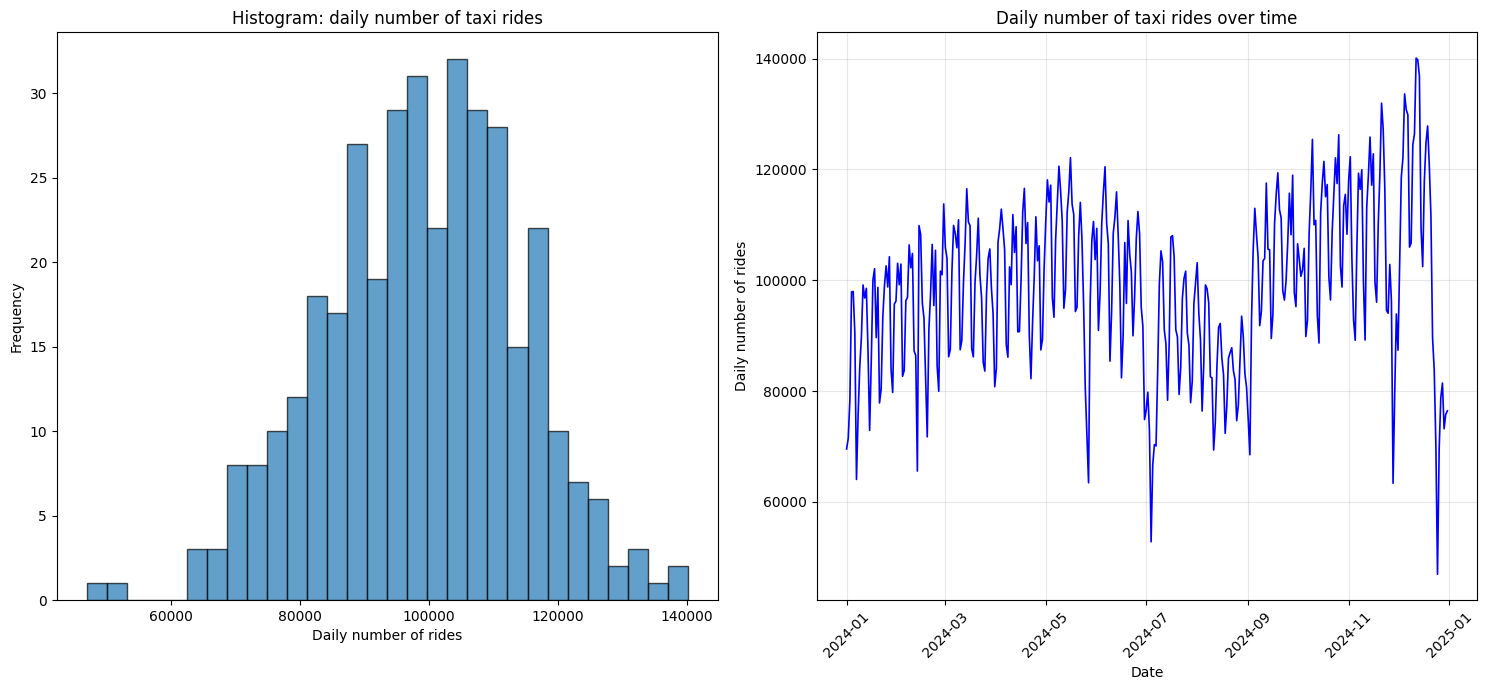

In [84]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
ax1.hist(dataset["total_rides"], bins=30, edgecolor='black', alpha=0.7)
ax1.set_xlabel("Daily number of rides")
ax1.set_ylabel("Frequency")
ax1.set_title("Histogram: daily number of taxi rides")

dataset_sorted = dataset.sort("date")
ax2.plot(dataset_sorted["date"],dataset_sorted["total_rides"], linewidth=1.2, color='blue')
ax2.set_xlabel("Date")
ax2.set_ylabel("Daily number of rides")
ax2.set_title("Daily number of taxi rides over time")
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

